# Analyse Meta Features 

In [15]:
import pandas as pd

## Setup


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.calibration import calibration_curve

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [17]:
master_df = pd.read_parquet('../data/dataset/master_df.parquet')

In [18]:
master_df_raw = master_df.copy()
print(f'Raw master_df shape: {master_df_raw.shape}')


Raw master_df shape: (108592, 146)


In [19]:
master_df

,date,open,high,low,close,adj_close,volume,ticker,ema_12,ema_26,...,cls_correct_GRU,cls_brier_20_GRU,cls_logloss_20_GRU,cls_acc_20_GRU,cls_brier_BiGRU,cls_logloss_BiGRU,cls_correct_BiGRU,cls_brier_20_BiGRU,cls_logloss_20_BiGRU,cls_acc_20_BiGRU
0,2012-09-04,95.108574,96.448570,94.928574,96.424286,87.121140,91973000.0,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-09-05,96.510002,96.621429,95.657143,95.747147,86.509338,84093800.0,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-09-06,96.167145,96.898575,95.828575,96.610001,87.288956,97799100.0,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-09-07,96.864288,97.497147,96.538574,97.205711,87.827171,82416600.0,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-09-10,97.207146,97.612854,94.585716,94.677139,85.542564,121999500.0,AAPL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108587,2017-08-28,76.900002,76.940002,76.260002,76.470001,76.470001,8229700.0,XOM,77.187452,78.267858,...,0.0,0.437900,1.345669,0.35,0.907000,3.044196,0.0,0.523072,1.572789,0.35
108588,2017-08-29,76.209999,76.489998,76.080002,76.449997,76.449997,7060400.0,XOM,77.073998,78.133202,...,0.0,0.460631,1.394931,0.30,0.907109,3.045400,0.0,0.567724,1.718716,0.30
108589,2017-08-30,76.239998,76.449997,76.059998,76.099998,76.099998,8218000.0,XOM,76.924151,77.982594,...,1.0,0.485051,1.448450,0.25,0.001890,0.044445,1.0,0.612453,1.865047,0.25
108590,2017-08-31,76.269997,76.489998,76.050003,76.330002,76.330002,15641700.0,XOM,76.832744,77.860180,...,1.0,0.468307,1.412751,0.30,0.003251,0.058710,1.0,0.575341,1.768015,0.30


In [20]:
# pd.set_option('display.max_rows', None, 'display.max_columns', None)
master_df.columns.tolist()

['date',
 'open',
 'high',
 'low',
 'close',
 'adj_close',
 'volume',
 'ticker',
 'ema_12',
 'ema_26',
 'ema_50',
 'macd_12_26_9',
 'macdh_12_26_9',
 'macds_12_26_9',
 'rsi_14',
 'stochrsik_14_14_3_3',
 'stochrsid_14_14_3_3',
 'atrr_14',
 'bb_upper',
 'bb_middle',
 'bb_lower',
 'obv',
 'ret_1d',
 'roll_ret_1d',
 'roll_ret_5d',
 'roll_ret_20d',
 'sentiment',
 'emotion_anger',
 'emotion_disgust',
 'emotion_fear',
 'emotion_joy',
 'emotion_neutral',
 'emotion_sadness',
 'emotion_surprize',
 'emotion_anger_pct',
 'emotion_disgust_pct',
 'emotion_fear_pct',
 'emotion_joy_pct',
 'emotion_neutral_pct',
 'emotion_sadness_pct',
 'emotion_surprize_pct',
 'positive_emotion',
 'negative_emotion',
 'uncertainty_emotion',
 'positive_emotion_pct',
 'negative_emotion_pct',
 'uncertainty_emotion_pct',
 'stance_label',
 'finbert_label',
 'stance_score',
 'finbert_score',
 'finbert_up',
 'finbert_down',
 'finbert_neutral',
 'sector',
 'company_name',
 'sector_open_mean',
 'sector_high_mean',
 'sector_low

In [21]:
columns_to_check = [
    # Base price/TA
    'open', 'high', 'low', 'close', 'adj_close',
    'volume', 'ema_12',
    'ema_26', 'ema_50', 'macd_12_26_9', 'macdh_12_26_9', 'macds_12_26_9',
    'rsi_14', 'stochrsik_14_14_3_3', 'stochrsid_14_14_3_3', 'atrr_14',
    'bb_upper', 'bb_middle', 'bb_lower', 'obv',
    'ret_1d', 'roll_ret_1d', 'roll_ret_5d', 'roll_ret_20d',

    # Sentiment (single)
    'sentiment',

    # Emotions
    'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy',
    'emotion_neutral', 'emotion_sadness', 'emotion_surprize',
    'emotion_anger_pct', 'emotion_disgust_pct', 'emotion_fear_pct',
    'emotion_joy_pct', 'emotion_neutral_pct', 'emotion_sadness_pct',
    'emotion_surprize_pct',

    # Unified emotion
    'positive_emotion', 'negative_emotion', 'uncertainty_emotion',
    'positive_emotion_pct', 'negative_emotion_pct', 'uncertainty_emotion_pct',

    # Stance
    'stance_label', 'stance_score',

    # FinBERT
    'finbert_label', 'finbert_score', 'finbert_up', 'finbert_down',
    'finbert_neutral',

    # Sector aggregates
    'sector_open_mean', 'sector_high_mean', 'sector_low_mean', 'sector_close_mean',
    'sector_volume_mean', 'sector_ret_1d', 'sector_ret_5d',
    'sector_ret_20d', 'sector_range', 'sector_vol_20d',
    'ema_12_sector', 'ema_26_sector', 'ema_50_sector', 'macd_12_26_9_sector',
    'macdh_12_26_9_sector', 'macds_12_26_9_sector', 'rsi_14_sector',
    'sector_bb_upper', 'sector_bb_middle', 'sector_bb_lower',
    'market_close', 'sector_rel_strength', 'sector_dispersion_1d',

    # Meta targets
    'ret_1d_meta',
    'up_1d_meta', 'has_meta_target',

    # Meta regression predictions
    'reg_pred_ret_1d_LSTM', 'reg_pred_ret_1d_BiLSTM', 'reg_pred_ret_1d_GRU',
    'reg_pred_ret_1d_BiGRU',

    # Regression errors/diagnostics
    'reg_err_ret_1d_LSTM', 'reg_abs_err_ret_1d_LSTM', 'reg_sq_err_ret_1d_LSTM',
    'reg_dir_correct_1d_LSTM', 'reg_abs_err_lag1_LSTM', 'reg_mae_20_LSTM',
    'reg_rmse_20_LSTM', 'reg_dir_acc_20_LSTM',

    'reg_err_ret_1d_BiLSTM', 'reg_abs_err_ret_1d_BiLSTM', 'reg_sq_err_ret_1d_BiLSTM',
    'reg_dir_correct_1d_BiLSTM', 'reg_abs_err_lag1_BiLSTM',
    'reg_mae_20_BiLSTM', 'reg_rmse_20_BiLSTM', 'reg_dir_acc_20_BiLSTM',

    'reg_err_ret_1d_GRU', 'reg_abs_err_ret_1d_GRU', 'reg_sq_err_ret_1d_GRU',
    'reg_dir_correct_1d_GRU', 'reg_abs_err_lag1_GRU',
    'reg_mae_20_GRU', 'reg_rmse_20_GRU', 'reg_dir_acc_20_GRU',

    'reg_err_ret_1d_BiGRU', 'reg_abs_err_ret_1d_BiGRU', 'reg_sq_err_ret_1d_BiGRU',
    'reg_dir_correct_1d_BiGRU', 'reg_abs_err_lag1_BiGRU',
    'reg_mae_20_BiGRU', 'reg_rmse_20_BiGRU', 'reg_dir_acc_20_BiGRU',

    # Meta classification predictions
    'cls_prob_up_1d_LSTM', 'cls_prob_up_1d_BiLSTM', 'cls_prob_up_1d_GRU',
    'cls_prob_up_1d_BiGRU',

    # Classification diagnostics
    'cls_brier_LSTM', 'cls_logloss_LSTM', 'cls_correct_LSTM',
    'cls_brier_20_LSTM', 'cls_logloss_20_LSTM', 'cls_acc_20_LSTM',

    'cls_brier_BiLSTM', 'cls_logloss_BiLSTM', 'cls_correct_BiLSTM',
    'cls_brier_20_BiLSTM', 'cls_logloss_20_BiLSTM', 'cls_acc_20_BiLSTM',

    'cls_brier_GRU', 'cls_logloss_GRU', 'cls_correct_GRU',
    'cls_brier_20_GRU', 'cls_logloss_20_GRU', 'cls_acc_20_GRU',

    'cls_brier_BiGRU', 'cls_logloss_BiGRU', 'cls_correct_BiGRU',
    'cls_brier_20_BiGRU', 'cls_logloss_20_BiGRU', 'cls_acc_20_BiGRU',
]

print(f"Initial master_df shape: {master_df.shape}")

master_df = master_df.dropna(subset=columns_to_check)

print(f"After dropping NaNs in selected columns, master_df shape: {master_df.shape}")

master_df.reset_index(drop=True, inplace=True)


Initial master_df shape: (108592, 146)
After dropping NaNs in selected columns, master_df shape: (81699, 146)


## Overview


In [22]:
print(f'Filtered master_df shape: {master_df.shape}')
print(f'Date range: {master_df['date'].min()} -> {master_df['date'].max()}')
print(f'Unique tickers: {master_df['ticker'].nunique()}')
rows_per_ticker = master_df.groupby('ticker').size()
print(rows_per_ticker.describe())


Filtered master_df shape: (81699, 146)
Date range: 2013-11-19 00:00:00 -> 2017-08-31 00:00:00
Unique tickers: 87
count     87.000000
mean     939.068966
std       81.083476
min      395.000000
25%      953.000000
50%      953.000000
75%      953.000000
max      953.000000
dtype: float64


## Missingness Before Filtering


cls_acc_20_BiGRU         0.246289
cls_acc_20_BiLSTM        0.246289
cls_brier_20_BiLSTM      0.246289
cls_acc_20_LSTM          0.246289
cls_logloss_20_LSTM      0.246289
cls_brier_20_LSTM        0.246289
reg_dir_acc_20_BiGRU     0.246289
reg_rmse_20_BiGRU        0.246289
reg_dir_acc_20_GRU       0.246289
reg_rmse_20_GRU          0.246289
reg_mae_20_GRU           0.246289
reg_dir_acc_20_BiLSTM    0.246289
reg_rmse_20_BiLSTM       0.246289
reg_mae_20_BiLSTM        0.246289
reg_dir_acc_20_LSTM      0.246289
reg_rmse_20_LSTM         0.246289
reg_mae_20_LSTM          0.246289
cls_logloss_20_BiLSTM    0.246289
reg_mae_20_BiGRU         0.246289
cls_logloss_20_GRU       0.246289
dtype: float64


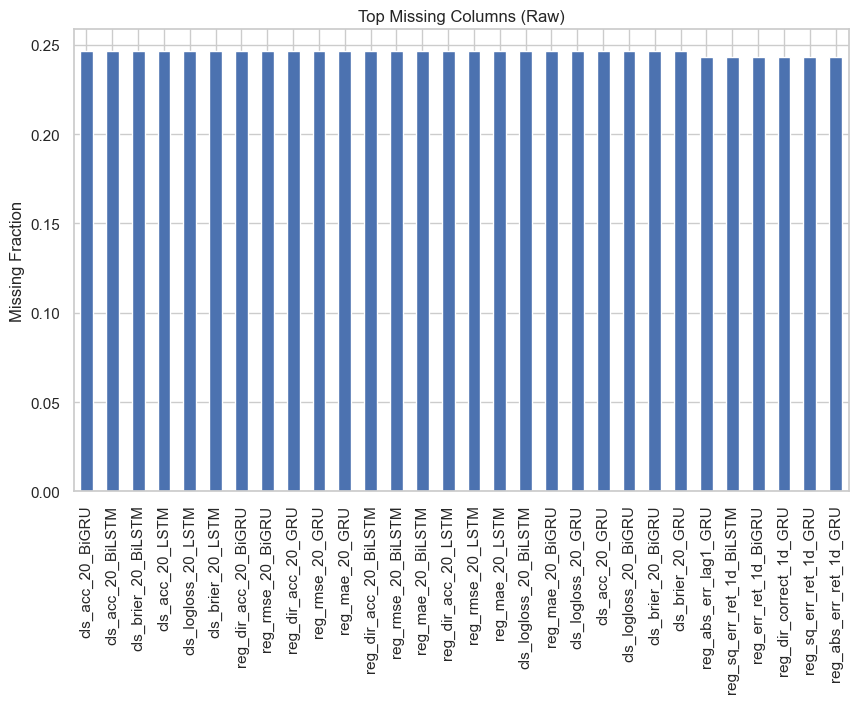

In [23]:
missing = master_df_raw.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing.head(20))
if not missing.empty:
    missing.head(30).plot(kind='bar')
    plt.title('Top Missing Columns (Raw)')
    plt.ylabel('Missing Fraction')
    plt.show()


## Targets Distribution


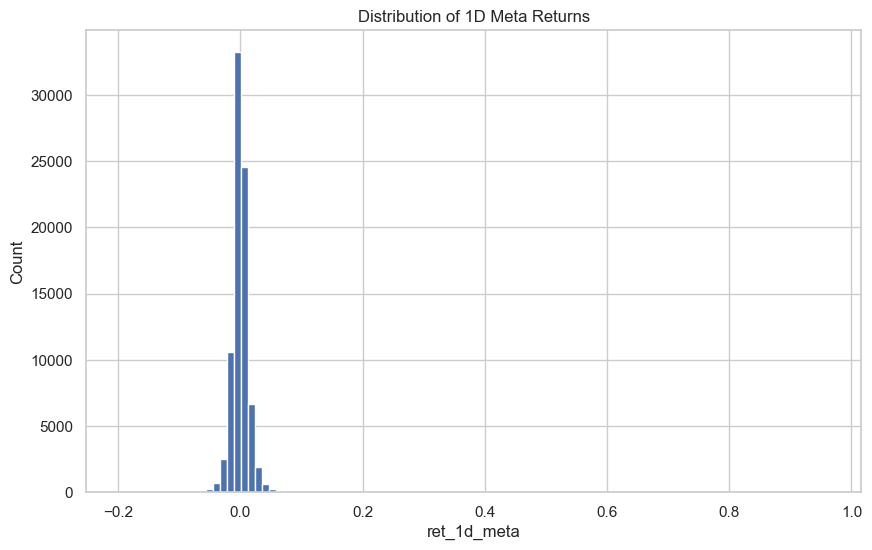

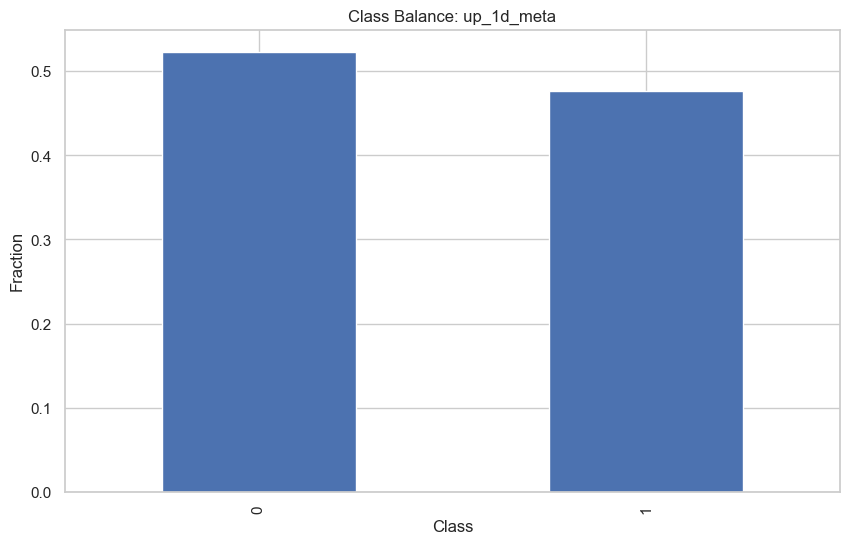

In [24]:
if 'ret_1d_meta' in master_df.columns:
    master_df['ret_1d_meta'].hist(bins=100)
    plt.title('Distribution of 1D Meta Returns')
    plt.xlabel('ret_1d_meta')
    plt.ylabel('Count')
    plt.show()
if 'up_1d_meta' in master_df.columns:
    master_df['up_1d_meta'].value_counts(normalize=True).sort_index().plot(kind='bar')
    plt.title('Class Balance: up_1d_meta')
    plt.xlabel('Class')
    plt.ylabel('Fraction')
    plt.show()


## Prediction Coverage


reg_pred_ret_1d_LSTM      1.0
reg_pred_ret_1d_BiLSTM    1.0
reg_pred_ret_1d_GRU       1.0
reg_pred_ret_1d_BiGRU     1.0
cls_prob_up_1d_LSTM       1.0
cls_prob_up_1d_BiLSTM     1.0
cls_prob_up_1d_GRU        1.0
cls_prob_up_1d_BiGRU      1.0
dtype: float64


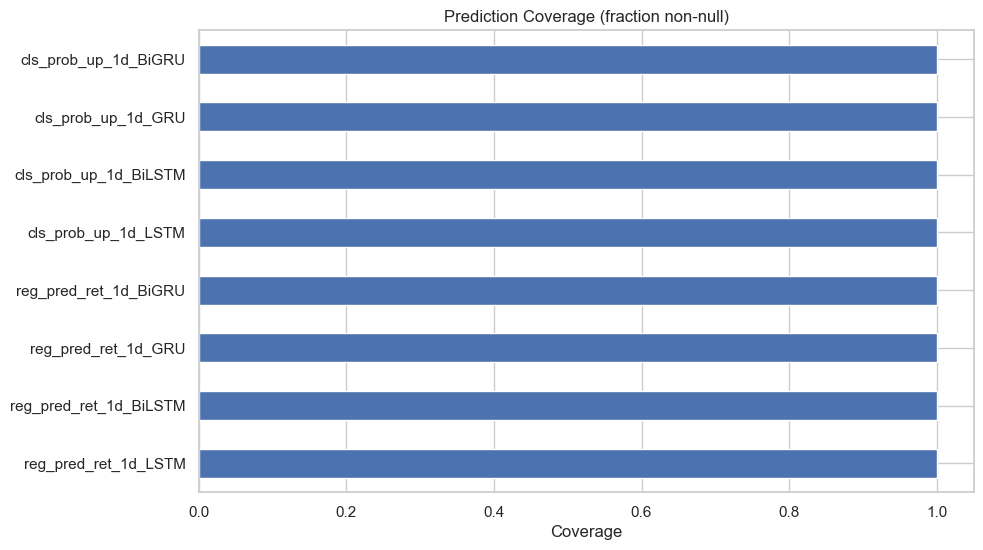

In [25]:
reg_pred_cols = [c for c in master_df.columns if c.startswith('reg_pred_ret_1d_')]
cls_prob_cols = [c for c in master_df.columns if c.startswith('cls_prob_up_1d_')]
coverage = {}
for c in reg_pred_cols + cls_prob_cols:
    coverage[c] = master_df[c].notna().mean()
coverage = pd.Series(coverage).sort_values()
print(coverage)
if not coverage.empty:
    coverage.plot(kind='barh')
    plt.title('Prediction Coverage (fraction non-null)')
    plt.xlabel('Coverage')
    plt.show()


## Regression: Pred vs Actual (Best Model, One Ticker per Sector)


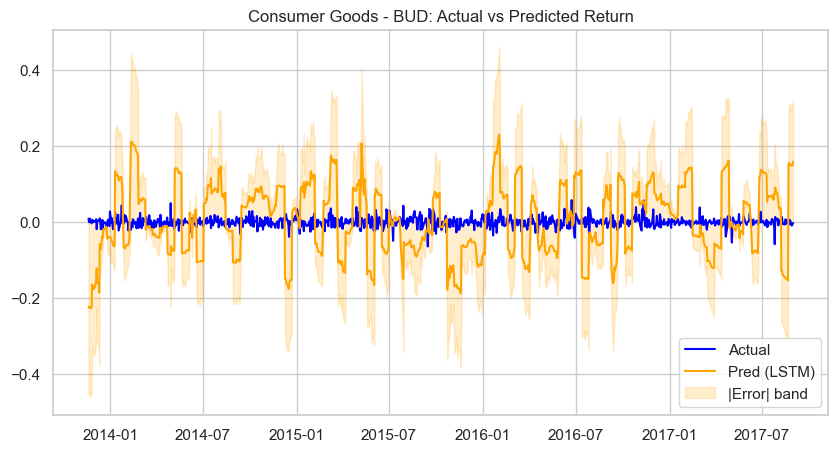

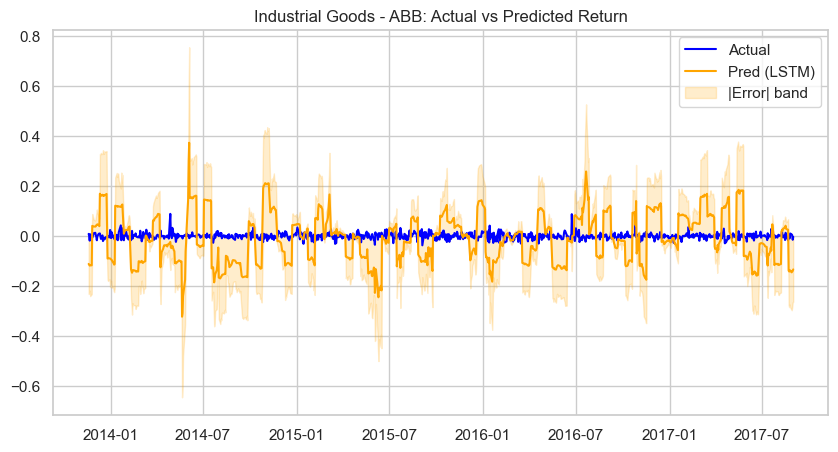

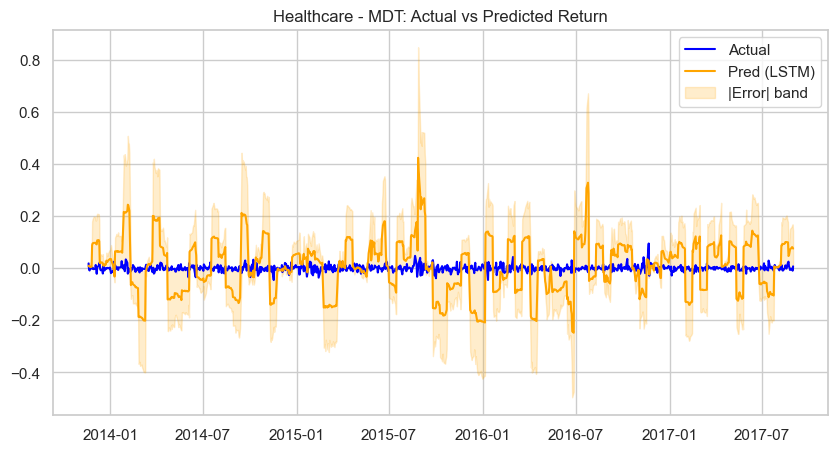

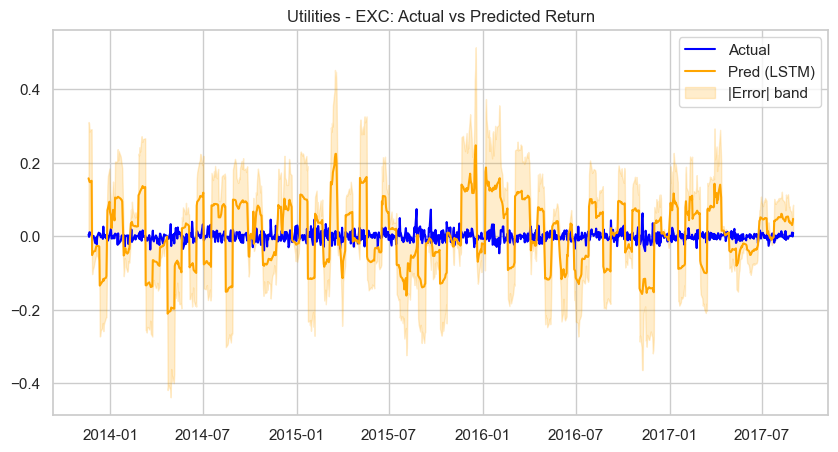

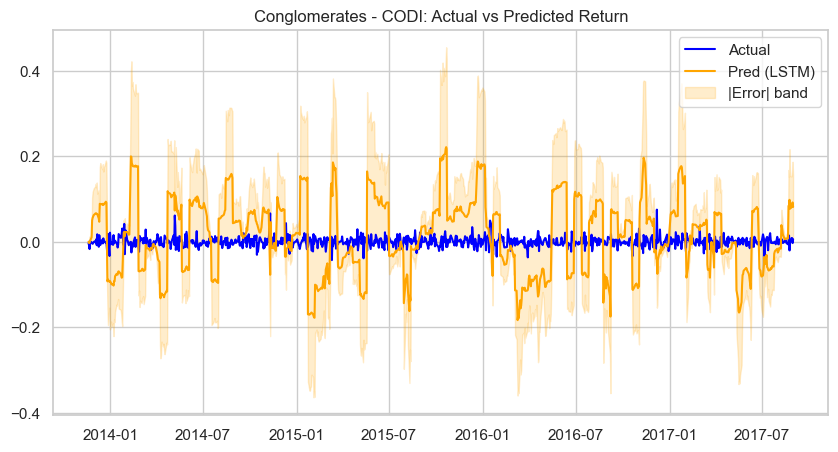

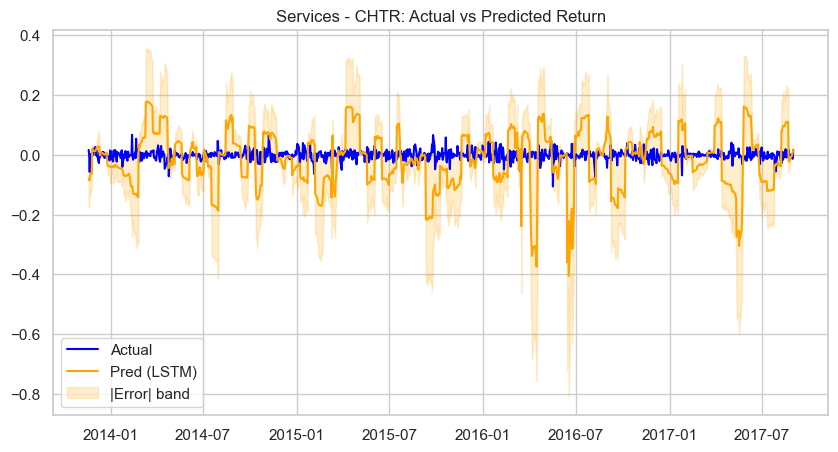

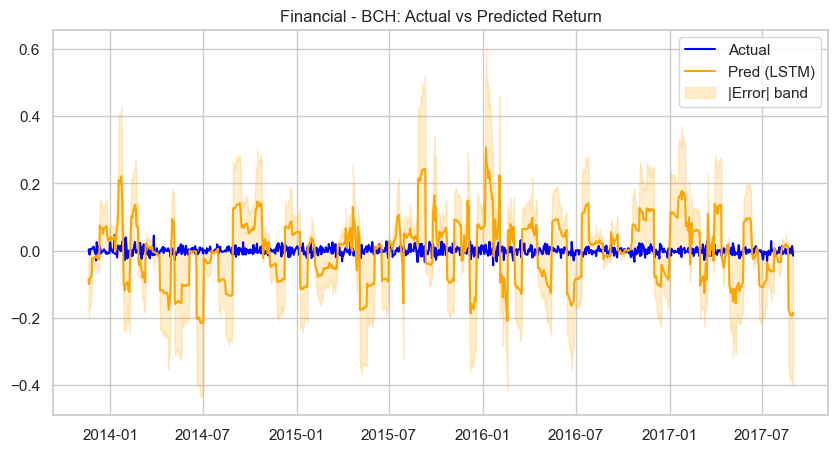

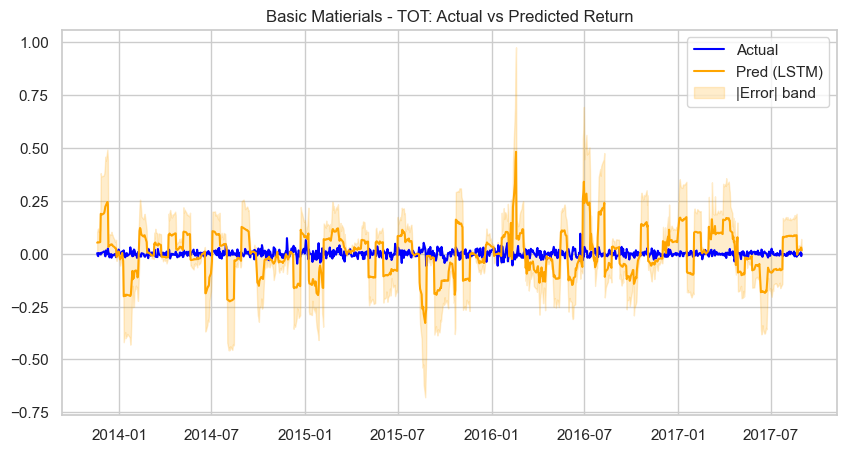

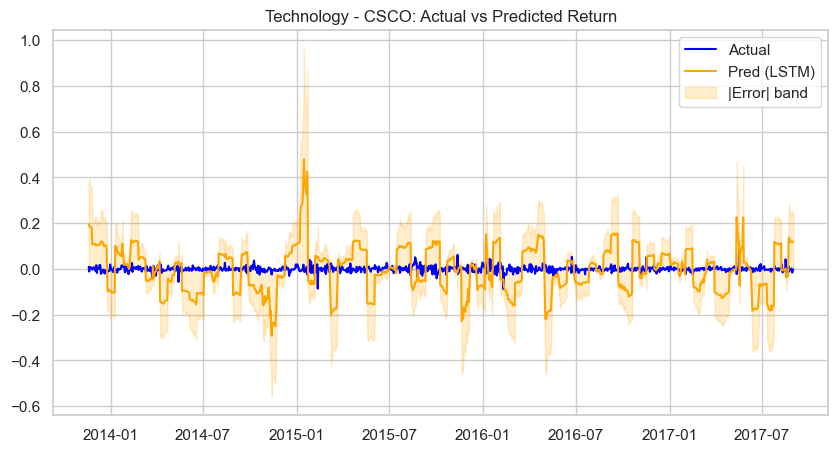

In [26]:
# Pick a model based on available columns
candidate_models = ['LSTM','BiLSTM','GRU','BiGRU']
plot_model = None
for m in candidate_models:
    if f'reg_pred_ret_1d_{m}' in master_df.columns:
        plot_model = m
        break
if plot_model is None:
    print('No regression prediction columns found.')
else:
    pred_col = f'reg_pred_ret_1d_{plot_model}'
    abs_err_col = f'reg_abs_err_ret_1d_{plot_model}'
    random.seed(42)
    sector_ticker_map = {}
    for sector in master_df['sector'].dropna().unique():
        tickers = master_df.loc[master_df['sector'] == sector, 'ticker'].dropna().unique()
        if len(tickers):
            sector_ticker_map[sector] = random.choice(tickers)
    for sector, ticker in sector_ticker_map.items():
        stock_data = master_df[master_df['ticker'] == ticker].dropna(subset=[pred_col, 'ret_1d_meta'])
        if stock_data.empty:
            continue
        stock_data = stock_data.sort_values('date')
        plt.figure(figsize=(10, 5))
        plt.plot(stock_data['date'], stock_data['ret_1d_meta'], label='Actual', color='blue')
        plt.plot(stock_data['date'], stock_data[pred_col], label=f'Pred ({plot_model})', color='orange')
        if abs_err_col in stock_data.columns:
            plt.fill_between(stock_data['date'],
                             stock_data[pred_col] - stock_data[abs_err_col],
                             stock_data[pred_col] + stock_data[abs_err_col],
                             color='orange', alpha=0.2, label='|Error| band')
        plt.title(f'{sector} - {ticker}: Actual vs Predicted Return')
        plt.legend()
        plt.grid(True)
        plt.show()


## Regression: Error Distributions by Model


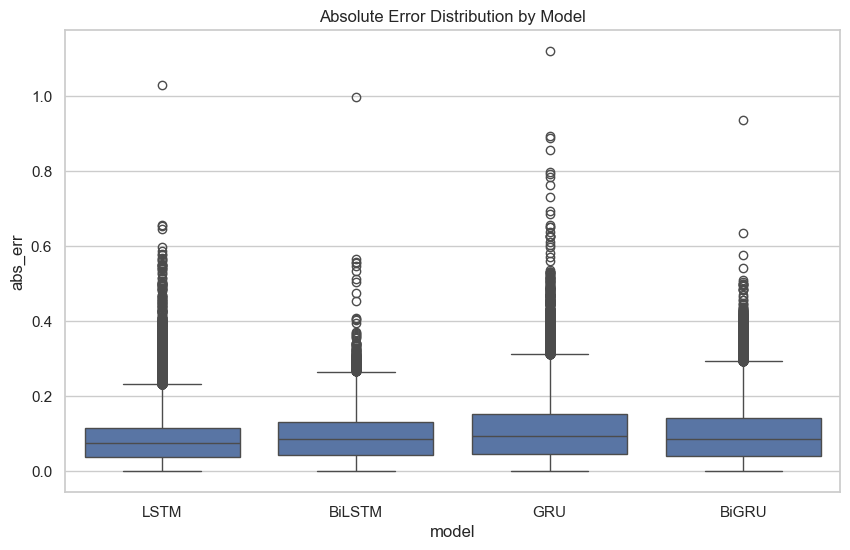

In [27]:
models = ['LSTM','BiLSTM','GRU','BiGRU']
err_cols = [f'reg_abs_err_ret_1d_{m}' for m in models if f'reg_abs_err_ret_1d_{m}' in master_df.columns]
if not err_cols:
    print('No regression error columns found.')
else:
    data = master_df[err_cols].melt(var_name='model', value_name='abs_err').dropna()
    data['model'] = data['model'].str.replace('reg_abs_err_ret_1d_', '', regex=False)
    sns.boxplot(data=data, x='model', y='abs_err')
    plt.title('Absolute Error Distribution by Model')
    plt.show()


## Regression: Directional Accuracy (Rolling)


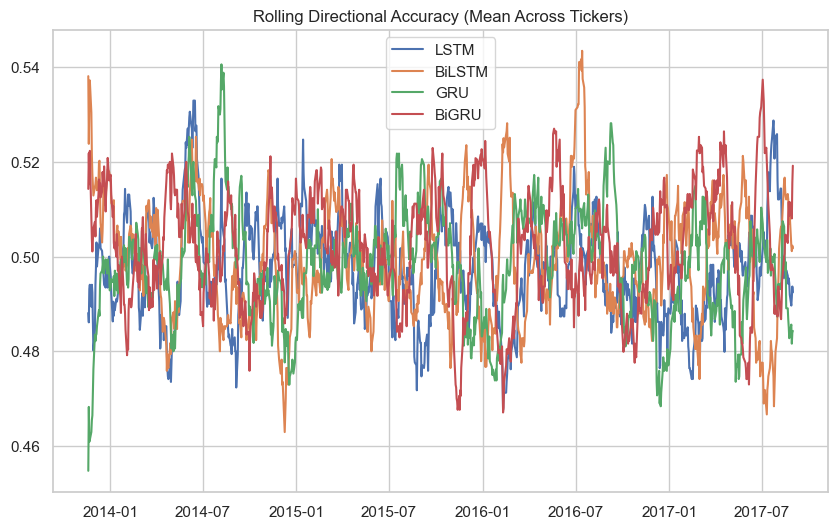

In [28]:
models = ['LSTM','BiLSTM','GRU','BiGRU']
for m in models:
    col = f'reg_dir_acc_20_{m}'
    if col in master_df.columns:
        series = master_df.groupby('date')[col].mean().dropna()
        plt.plot(series.index, series.values, label=m)
if plt.gca().has_data():
    plt.title('Rolling Directional Accuracy (Mean Across Tickers)')
    plt.legend()
    plt.show()


## Classification: Calibration Curves


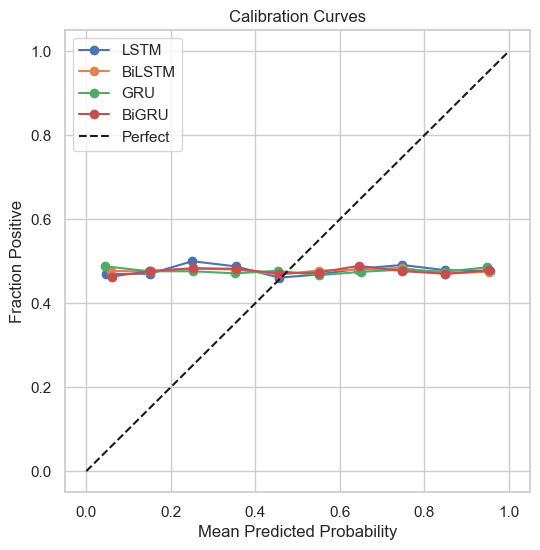

In [29]:
models = ['LSTM','BiLSTM','GRU','BiGRU']
if 'up_1d_meta' not in master_df.columns:
    print('No up_1d_meta column found.')
else:
    plt.figure(figsize=(6,6))
    for m in models:
        col = f'cls_prob_up_1d_{m}'
        if col not in master_df.columns:
            continue
        df = master_df[[col, 'up_1d_meta']].dropna()
        if df.empty:
            continue
        frac_pos, mean_pred = calibration_curve(df['up_1d_meta'], df[col], n_bins=10)
        plt.plot(mean_pred, frac_pos, marker='o', label=m)
    plt.plot([0,1],[0,1],'k--', label='Perfect')
    plt.title('Calibration Curves')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction Positive')
    plt.legend()
    plt.grid(True)
    plt.show()


## Classification: Probability Distributions


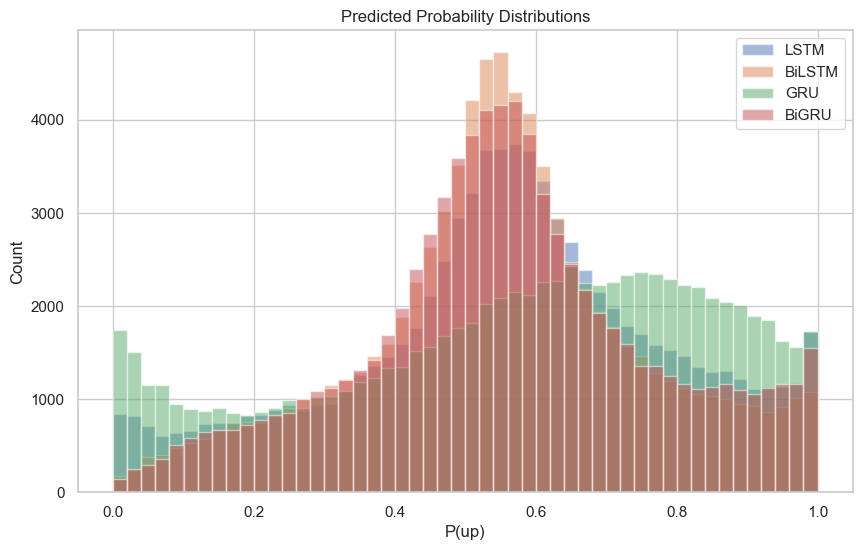

In [30]:
models = ['LSTM','BiLSTM','GRU','BiGRU']
for m in models:
    col = f'cls_prob_up_1d_{m}'
    if col in master_df.columns:
        master_df[col].dropna().hist(bins=50, alpha=0.5, label=m)
if plt.gca().has_data():
    plt.title('Predicted Probability Distributions')
    plt.xlabel('P(up)')
    plt.ylabel('Count')
    plt.legend()
    plt.show()


## Classification: Rolling Brier / LogLoss


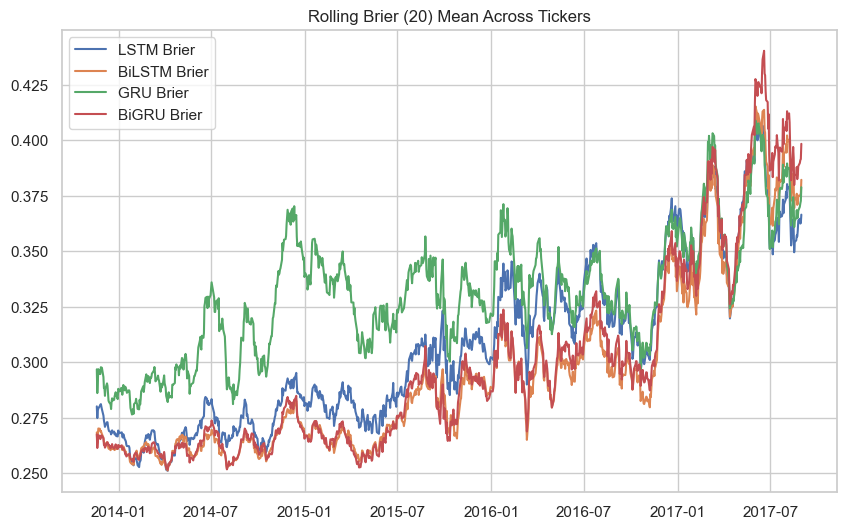

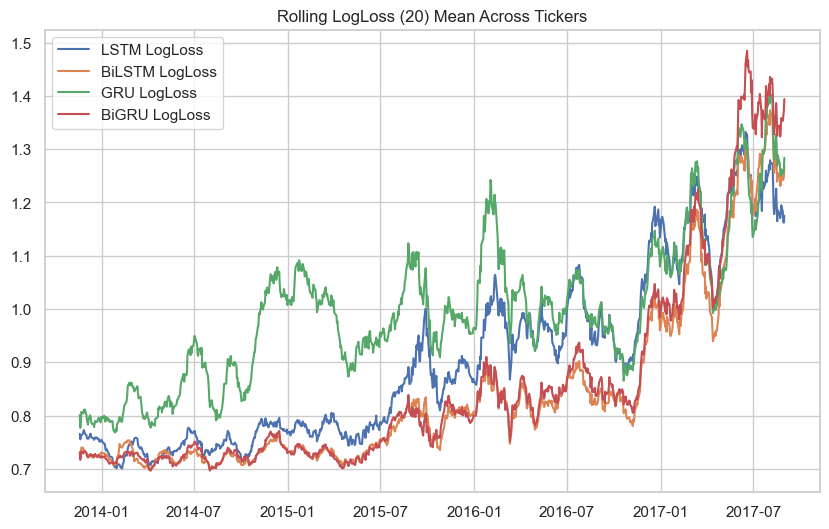

In [31]:
models = ['LSTM','BiLSTM','GRU','BiGRU']
for m in models:
    col = f'cls_brier_20_{m}'
    if col in master_df.columns:
        series = master_df.groupby('date')[col].mean().dropna()
        plt.plot(series.index, series.values, label=f'{m} Brier')
if plt.gca().has_data():
    plt.title('Rolling Brier (20) Mean Across Tickers')
    plt.legend()
    plt.show()
for m in models:
    col = f'cls_logloss_20_{m}'
    if col in master_df.columns:
        series = master_df.groupby('date')[col].mean().dropna()
        plt.plot(series.index, series.values, label=f'{m} LogLoss')
if plt.gca().has_data():
    plt.title('Rolling LogLoss (20) Mean Across Tickers')
    plt.legend()
    plt.show()


## Correlation Heatmap (Meta Targets & Predictions)


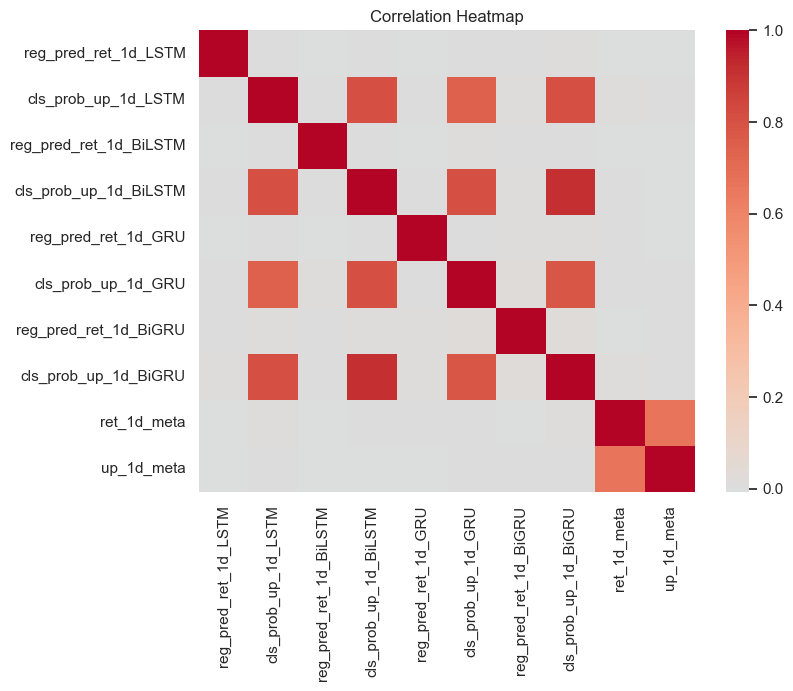

In [32]:
cols = []
for m in ['LSTM','BiLSTM','GRU','BiGRU']:
    c = f'reg_pred_ret_1d_{m}'
    if c in master_df.columns: cols.append(c)
    c = f'cls_prob_up_1d_{m}'
    if c in master_df.columns: cols.append(c)
if 'ret_1d_meta' in master_df.columns: cols.append('ret_1d_meta')
if 'up_1d_meta' in master_df.columns: cols.append('up_1d_meta')
if cols:
    corr = master_df[cols].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap')
    plt.show()


## Sector Comparison: Regression MAE by Model


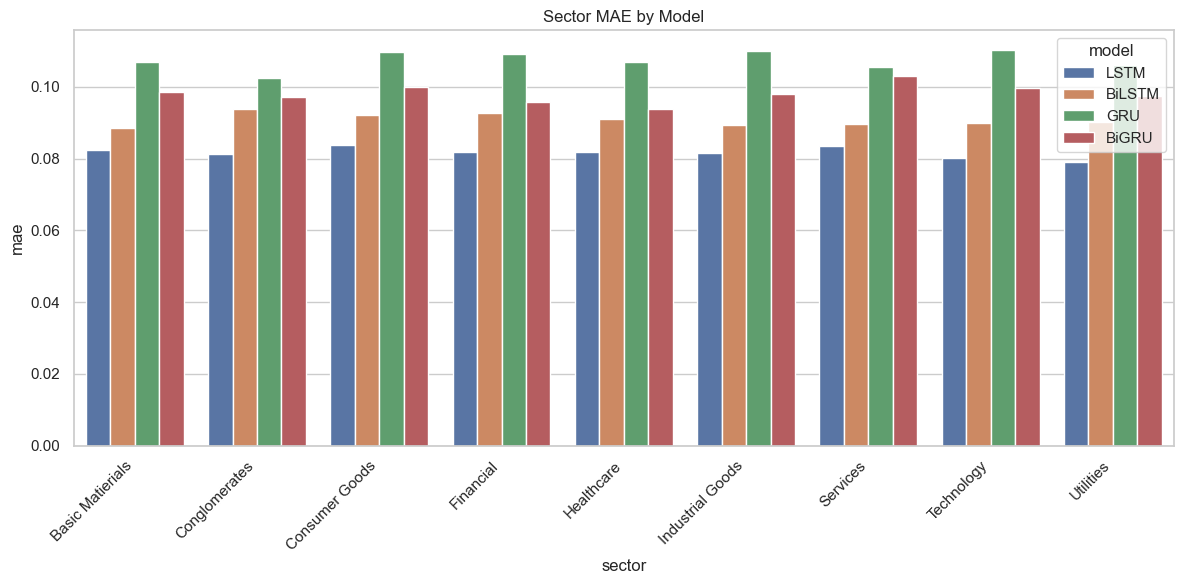

In [33]:
models = ['LSTM','BiLSTM','GRU','BiGRU']
if 'sector' not in master_df.columns:
    print('No sector column found.')
else:
    rows = []
    for m in models:
        col = f'reg_abs_err_ret_1d_{m}'
        if col not in master_df.columns:
            continue
        grp = master_df.groupby('sector')[col].mean().dropna()
        for sector, val in grp.items():
            rows.append({'model': m, 'sector': sector, 'mae': val})
    if rows:
        df = pd.DataFrame(rows)
        plt.figure(figsize=(12,6))
        sns.barplot(data=df, x='sector', y='mae', hue='model')
        plt.xticks(rotation=45, ha='right')
        plt.title('Sector MAE by Model')
        plt.tight_layout()
        plt.show()
